<a href="https://colab.research.google.com/github/lillymitch/organized_archives/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation: Training Transforms

In [5]:
## Training Transforms
from torchvision import transforms

train_processor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_processor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Import and Condense Dataset

In [6]:
import shutil
import os
from datasets import load_dataset, Image as HFImage
from PIL import Image
from io import BytesIO

wikiart_dataset = load_dataset(
    "huggan/wikiart",
    split="train",
    streaming=True
)

wikiart_dataset = wikiart_dataset.cast_column("image", HFImage(decode=False))
style_names = wikiart_dataset.features["style"].names

#defines path for small dataset to be created locally
small_dataset_path = "/content/wikiart_small"

#removes old dataset folder if it already exists, and creates new one
if os.path.exists(small_dataset_path):
    shutil.rmtree(small_dataset_path)
os.makedirs(small_dataset_path, exist_ok=True)

#classes to include
selected_classes = [
    "Impressionism",
    "Cubism",
    "Baroque",
    "Realism",
    "Expressionism",
]

#change later
max_per_class = 100

max_examples_to_check = 3000
examples_checked = 0
class_counts = {class_name: 0 for class_name in selected_classes}

#condense the dataset
for example in wikiart_dataset:

    examples_checked += 1
    if examples_checked >= max_examples_to_check:
        print("stopped early")
        break

    style_index = example["style"]
    style_name = style_names[style_index]

    #ONLY process if the style is in selected_classes and we haven't reached max_per_class for this style
    if style_name in selected_classes and class_counts[style_name] < max_per_class:

        class_folder = os.path.join(small_dataset_path, style_name)
        os.makedirs(class_folder, exist_ok=True)
        image_data = example["image"]

        #chatgpt try and except
        try:
            if image_data.get("bytes") is not None:
                image = Image.open(BytesIO(image_data["bytes"])).convert("RGB")
            else:
                image = Image.open(image_data["path"]).convert("RGB")
            save_path = os.path.join(
                class_folder,
                f"{class_counts[style_name]}.jpg"
            )

            image.save(save_path)
            class_counts[style_name] += 1
            print(class_counts)

        except:
            pass

    if all(class_counts[class_name] >= max_per_class for class_name in selected_classes):
        break

print("small dataset created")
print(class_counts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

{'Impressionism': 0, 'Cubism': 0, 'Baroque': 0, 'Realism': 1, 'Expressionism': 0}
{'Impressionism': 0, 'Cubism': 0, 'Baroque': 1, 'Realism': 1, 'Expressionism': 0}
{'Impressionism': 1, 'Cubism': 0, 'Baroque': 1, 'Realism': 1, 'Expressionism': 0}
{'Impressionism': 1, 'Cubism': 0, 'Baroque': 1, 'Realism': 2, 'Expressionism': 0}
{'Impressionism': 1, 'Cubism': 0, 'Baroque': 1, 'Realism': 3, 'Expressionism': 0}
{'Impressionism': 1, 'Cubism': 0, 'Baroque': 1, 'Realism': 4, 'Expressionism': 0}
{'Impressionism': 2, 'Cubism': 0, 'Baroque': 1, 'Realism': 4, 'Expressionism': 0}
{'Impressionism': 2, 'Cubism': 0, 'Baroque': 1, 'Realism': 5, 'Expressionism': 0}
{'Impressionism': 2, 'Cubism': 0, 'Baroque': 2, 'Realism': 5, 'Expressionism': 0}
{'Impressionism': 2, 'Cubism': 0, 'Baroque': 2, 'Realism': 6, 'Expressionism': 0}
{'Impressionism': 3, 'Cubism': 0, 'Baroque': 2, 'Realism': 6, 'Expressionism': 0}
{'Impressionism': 3, 'Cubism': 0, 'Baroque': 2, 'Realism': 6, 'Expressionism': 1}
{'Impressionism'

In [7]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

#ImageFolder dataset created from the condensed dataset
dataset = ImageFolder(
    root=small_dataset_path,
    transform=train_processor
)

#structural test
print(len(dataset))
print(dataset.classes)

print("dataset size:", len(dataset))
print("classes:", dataset.classes)

478
['Baroque', 'Cubism', 'Expressionism', 'Impressionism', 'Realism']
dataset size: 478
classes: ['Baroque', 'Cubism', 'Expressionism', 'Impressionism', 'Realism']


## Example Images from Each Art Class

Baroque


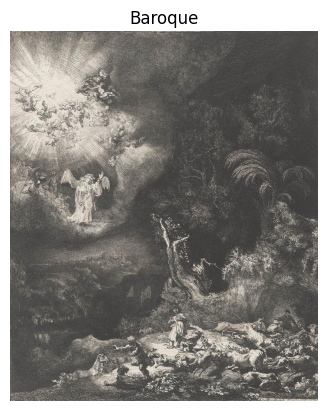

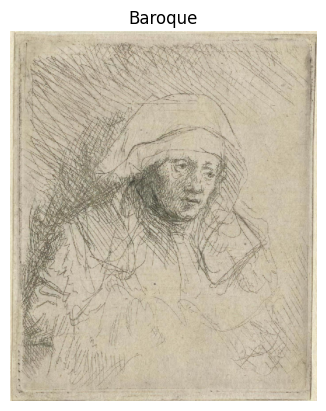

Cubism


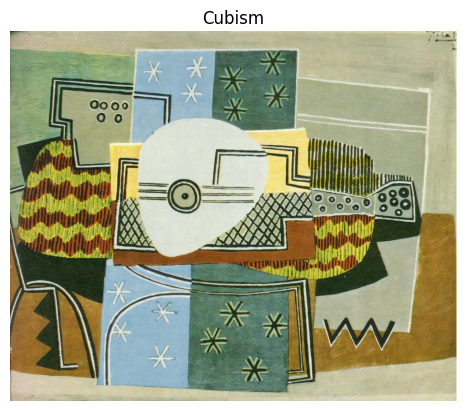

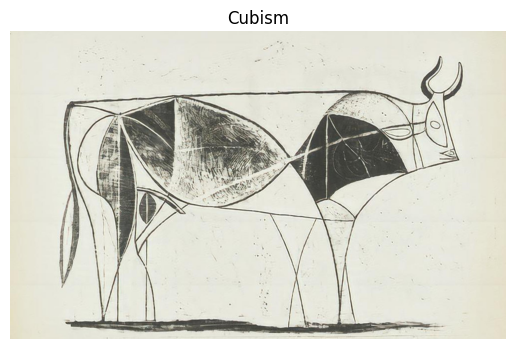

Expressionism


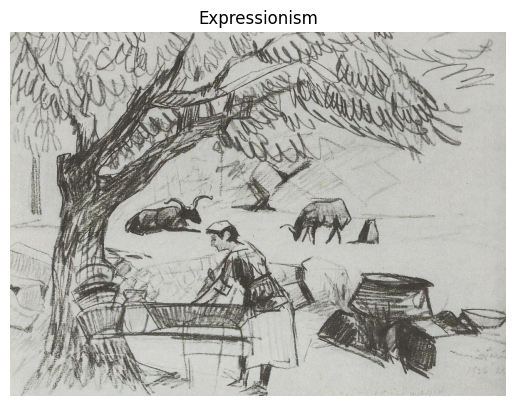

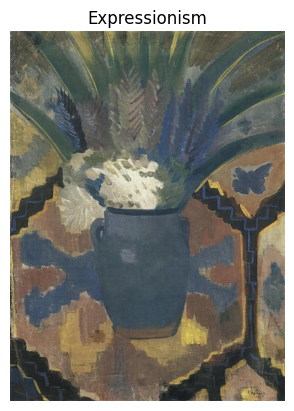

Impressionism


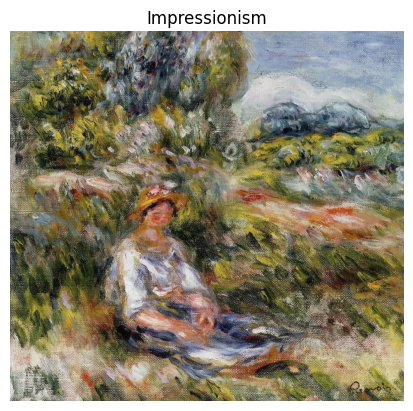

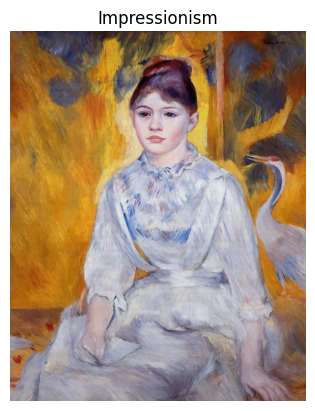

Realism


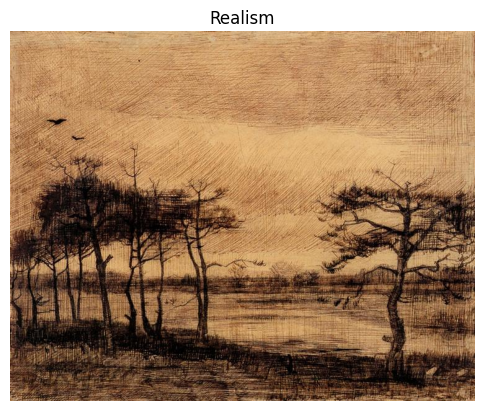

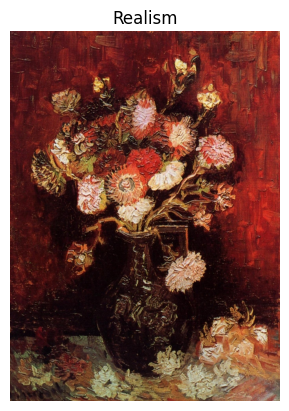

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

#------show examples from each class of art--------

for class_name in dataset.classes:

    print(class_name)
    class_index = dataset.class_to_idx[class_name]
    examples = [sample for sample in dataset.samples if sample[1] == class_index][:2]

    for file_path, label in examples:

        img = Image.open(file_path)
        plt.imshow(img)
        plt.title(dataset.classes[label])
        plt.axis("off")
        plt.show()

## Split Data

In [9]:
from torch.utils.data import DataLoader, random_split

#split ratios for training, validation, and testing
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

#split data
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

num_classes = len(dataset.classes)

## Compute Confusion Matrix

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU if available, else CPU

def evaluate(model, data_loader):

    model.eval()

    #initialize conf matx
    num_classes = len(dataset.classes)
    conf_mat = torch.zeros((num_classes, num_classes), dtype=torch.int32)

    #define loss
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            #loss val
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            #scale loss by num samples in batch
            total_loss += loss.item() * images.size(0)

            #get the predicted class labels
            #by finding the index of the max logit
            predicted_labels = torch.argmax(outputs, dim=1)

            # Update the confusion matrix based on true and predicted labels
            for i in range(len(labels)):
                true_label = labels[i].item()
                predicted_label = predicted_labels[i].item()
                conf_mat[true_label, predicted_label] += 1

    #ChatGPT

    # Calculate overall accuracy from the confusion matrix (sum of diagonal elements / total samples)
    accuracy = torch.diag(conf_mat).sum() / conf_mat.sum()
    # Calculate the average loss over the entire dataset
    average_loss = total_loss / len(data_loader.dataset)

    # Return the accuracy, average loss, and the confusion matrix
    return accuracy.item(), average_loss, conf_mat

## ResNet18 Transfer Learning

In [11]:
## ResNet18 transfer learning
from torchvision import models
import torch.nn as nn

def build_transfer_model(num_classes):
  model = models.resnet18(pretrained=True)

  # freeze most layers
  for param in model.parameters():
    param.requires_grad = False

  # unfreeze last layer block (for better performance)
  for param in model.layer4.parameters():
    param.requires_grad = True

  # replace final layer
  model.fc = nn.Linear(model.fc.in_features, num_classes)

  return model

## Convolutional Neural Network

In [12]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        #the image passes through these layers in order
        #convolution layers learn textures and visual patterns
        #relu adds nonlinearity
        #max pooling reduces image size while keeping important features
        self.pipeline = nn.Sequential(

            nn.Conv2d(3, 16, 5),
            nn.MaxPool2d(2, 2),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3),
            nn.MaxPool2d(2, 2),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3),
            nn.MaxPool2d(2, 2),
            nn.ReLU(),

            #adaptive pooling reduces each feature map to 1x1
            #linear layers use learned image features to predict the class
            nn.AdaptiveAvgPool2d((4, 4)), #changed to 4x4
            nn.Flatten(),
            nn.Linear(64*4*4, 128), #changed to 4x4
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.pipeline(x)

## Model Architecture: Logistic Regression

In [13]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a simple Logistic Regression model for image data
class LogisticRegression(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Input image is 3x224x224. Flatten to 3 * 224 * 224 features.
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3 * 224 * 224, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)

# Define the cross-entropy loss function
def cross_entropy_loss(outputs, targets):
    return F.cross_entropy(outputs, targets)

## Trainer Class for Model Management

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


class Trainer:

    def __init__(self, model, train_loader, val_loader, test_loader, optimizer, loss_fn, num_classes, device):
        """
        stores all variables needed for training/testing

        """

        self.model = model.to(device)

        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader

        self.optimizer = optimizer
        self.loss_fn = loss_fn

        self.num_classes = num_classes
        self.device = device

        #stores loss/accuracy values over time
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": []
        }


    def evaluate(self, data_loader):
        """
        evaluates the model on a dataset
        and computes accuracy/loss

        params:
            data_loader: dataset loader to evaluate on

        returns:
            accuracy.item(): classification accuracy
            average_loss: average loss across dataset
            conf_mat: confusion matrix
          """
        #puts model into evaluation mode
        self.model.eval()

        #confusion matrix
        conf_mat = torch.zeros(
            (self.num_classes, self.num_classes),
            dtype=torch.int32
        )

        total_loss = 0

        #turns off gradient calculations
        with torch.no_grad():

            for images, labels in data_loader:

                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)

                #computes loss
                loss = self.loss_fn(outputs, labels)

                total_loss += loss.item() * images.size(0)

                #finds predicted class
                predicted_labels = torch.argmax(outputs, dim=1)

                #fills confusion matrix
                for i in range(len(labels)):

                    true_label = labels[i].item()
                    predicted_label = predicted_labels[i].item()

                    conf_mat[true_label, predicted_label] += 1

        #computes overall accuracy
        accuracy = torch.diag(conf_mat).sum() / conf_mat.sum()

        average_loss = total_loss / len(data_loader.dataset)

        return accuracy.item(), average_loss, conf_mat


    def train(self, num_epochs=1000):
        """
        trains the model for a given
        number of epochs
        """

        print("starting training...")

        for epoch in range(num_epochs):

            #puts model into training mode
            self.model.train()

            epoch_total_loss = 0.0

            for images, labels in self.train_loader:

                images = images.to(self.device)
                labels = labels.to(self.device)

                #clears old gradients
                self.optimizer.zero_grad()

                outputs = self.model(images)

                #computes loss
                loss = self.loss_fn(outputs, labels)

                #runs backpropagation
                loss.backward()

                #updates weights
                self.optimizer.step()

                epoch_total_loss += loss.item() * images.size(0)

            #evaluates model after each epoch
            training_accuracy, training_loss, _ = self.evaluate(self.train_loader)

            validation_accuracy, validation_loss, _ = self.evaluate(self.val_loader)

            #stores results
            self.history["train_loss"].append(training_loss)
            self.history["train_acc"].append(training_accuracy)

            self.history["val_loss"].append(validation_loss)
            self.history["val_acc"].append(validation_accuracy)

            print("epoch:", epoch + 1)
            print("training accuracy:", round(training_accuracy, 4))
            print("validation accuracy:", round(validation_accuracy, 4))

        print("training finished.")

        return self.history


    def test(self):
        """
        tests the final trained model
        on the test dataset
        """

        print("starting testing...")

        test_accuracy, test_loss, test_confusion_matrix = self.evaluate(
            self.test_loader
        )

        print("test accuracy:", round(test_accuracy, 4))
        print("test loss:", round(test_loss, 4))

        print("test confusion matrix:")
        print(test_confusion_matrix)

        print("testing finished.")

        return test_accuracy, test_loss, test_confusion_matrix

## Optimizer Comparison Function

In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import Callable, Dict

def test_optimizer(model_builder_function: Callable[[], nn.Module],n_epochs: int = 10) -> None:
    """
    Compares the training loss curves of different optimizers and learning rates
    for a given model architecture.

    Args:
        model_builder_function: A callable that returns a new instance of the model.
                                This ensures each optimizer starts with an identical
                                model state.
        n_epochs: The number of training epochs to run for each optimizer.
    """
    #learning rates for comparison: 'small' (standard) and 'large' (aggressive)
    small_alpha = 1e-4
    large_alpha = 1e-3


    #testing configuration for different optimizers to be tested
    #every entry specifies the optimizer class, learning rate, and momentum (if applicable)
    optimizers_config: Dict[str, Dict[str, any]] = { # 'any' is used for the optimizer_class type
        "Gradient descent": {'lr': small_alpha, 'momentum': 0.0, 'optimizer_class': torch.optim.SGD},
        "Gradient descent (high learning rate)": {'lr': large_alpha, 'momentum': 0.0, 'optimizer_class': torch.optim.SGD},
        "Momentum": {'lr': small_alpha, 'momentum': 0.9, 'optimizer_class': torch.optim.SGD},
        "Momentum (high learning rate)": {'lr': large_alpha, 'momentum': 0.9, 'optimizer_class': torch.optim.SGD},
        "Adam": {'lr': small_alpha, 'optimizer_class': torch.optim.Adam},
        "Adam (high learning rate)": {'lr': large_alpha, 'optimizer_class': torch.optim.Adam},
    }

    losses_dict: Dict[str, list[float]] = {} # Dictionary to store loss history for each optimizer

    #iterates through each optimizer configuration
    for name, config in optimizers_config.items():

        model = model_builder_function()
        model.to(device)

        optimizer_params = {'lr': config['lr']} #creates optimizer instance
        if 'momentum' in config:
            optimizer_params['momentum'] = config['momentum']
        optimizer = config['optimizer_class'](model.parameters(), **optimizer_params)

        #sanity check (print initial loss)
        model.eval()
        initial_total_loss = 0.0
        with torch.no_grad():
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = cross_entropy_loss(outputs, labels)
                initial_total_loss += loss.item() * images.size(0)
        initial_avg_epoch_loss = initial_total_loss / len(train_loader.dataset)
        print(f"Initial loss for {name}: {initial_avg_epoch_loss:.4f}")

        losses_dict[name] = []
        losses_dict[name].append(initial_avg_epoch_loss)

        #training loop
        for epoch in range(n_epochs):
            model.train()
            epoch_total_loss = 0.0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()

                outputs = model(images)
                #loss
                loss = cross_entropy_loss(outputs, labels)
                loss.backward()
                optimizer.step()

                epoch_total_loss += loss.item() * images.size(0)

            #stores average loss at current epoch
            avg_epoch_loss = epoch_total_loss / len(train_loader.dataset)
            losses_dict[name].append(avg_epoch_loss)

    # --- Plotting Results ---
    fig, axarr = plt.subplots(1, 3, figsize=(15, 5), sharey=True) # Increased figsize for better readability
    fig.suptitle("Training Loss for Different Optimizers", fontsize=16) # Main title for the figure

    optimizer_types = ["Gradient descent", "Momentum", "Adam"]
    ax_map = {opt_type: i for i, opt_type in enumerate(optimizer_types)}

    #ChatGPT helped me compile this but I wrote the starter code myslef

    for name, losses in losses_dict.items():
        # Determine the subplot index based on optimizer type
        current_optimizer_type = name.split(" (")[0]
        ax_idx = ax_map.get(current_optimizer_type)

        if ax_idx is None:
            continue # Skip if optimizer type not recognized

        # Determine label and linestyle based on learning rate
        is_high_lr = "high learning rate" in name
        plot_label = f"{'High LR' if is_high_lr else 'Standard LR'}"
        alpha_val = large_alpha if is_high_lr else small_alpha
        linestyle = '-' if is_high_lr else '--'

        axarr[ax_idx].plot(losses, label=r"$\alpha = $" + f"{alpha_val:.0e} ({plot_label})", linestyle=linestyle)
        axarr[ax_idx].set_title(current_optimizer_type, fontsize=12)
        axarr[ax_idx].grid(True, linestyle='--', alpha=0.7) # Add grid for readability

    # Set common labels and legend for each subplot
    for ax in axarr:
        ax.set_xlabel("Epoch", fontsize=10)
        ax.legend(fontsize=9) # Add legend to each subplot for clarity
        ax.tick_params(axis='both', which='major', labelsize=8)

    axarr[0].set_ylabel("Average Training Loss", fontsize=10) # Only first subplot needs Y-label

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

## Training Loop Function

In [16]:
import torch

def train_model(model, train_loader, val_loader, optimizer, cross_entropy_loss, num_epochs=1000):

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} #for debugging

  for epoch in range(num_epochs):

    model.train()

    for images, labels in train_loader:

      #move images and labels to same gpu
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = cross_entropy_loss(outputs, labels)
      loss.backward()
      optimizer.step() #update params

    #evaluate train data after epoch
    training_accuracy, training_loss, training_confusion_matrix = evaluate(model, train_loader)

    #evaluate val data after epoch
    validation_accuracy, validation_loss, validation_confusion_matrix = evaluate(model, val_loader)

    history['train_loss'].append(training_loss)
    history['train_acc'].append(training_accuracy)

    history['val_loss'].append(validation_loss)
    history['val_acc'].append(validation_accuracy)

    print("epoch:", epoch + 1)
    print("training accuracy:", training_accuracy)
    print("validation accuracy:", validation_accuracy)

  return history

## Main Execution Block

In [17]:
# Define a lambda function to build a new LogisticRegression model for each optimizer test.
# This ensures each optimizer starts with the same initial model state.
model_builder_for_test = lambda: LogisticRegression(num_classes=num_classes)

# Call the test_optimizer function with the model builder and the number of epochs.
# This function will train the Logistic Regression model using different optimizers and plot their loss curves.
test_optimizer(model_builder_for_test, n_epochs=10)

Initial loss for Gradient descent: 1.7189


KeyboardInterrupt: 

In [18]:
#trains and evaluates the CNN model using the Adam optimizer.

if __name__ == "__main__":

    # build model
    model = CNN(num_classes).to(device)

    # define optimizer
    # we tested different optimizers and found Adam performed best
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    # train model
    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        cross_entropy_loss,
        num_epochs=5
    )

    # compute final test accuracy
    test_accuracy, test_loss, test_confusion_matrix = evaluate(
        model,
        test_loader
    )

    # print final results
    print("test accuracy:", test_accuracy)
    print("test loss:", test_loss)
    print(test_confusion_matrix)

epoch: 1
training accuracy: 0.200598806142807
validation accuracy: 0.28169015049934387
epoch: 2
training accuracy: 0.227544903755188
validation accuracy: 0.23943662643432617
epoch: 3
training accuracy: 0.2514970004558563
validation accuracy: 0.26760563254356384
epoch: 4
training accuracy: 0.30239519476890564
validation accuracy: 0.2957746386528015
epoch: 5
training accuracy: 0.29640719294548035
validation accuracy: 0.30985915660858154
test accuracy: 0.232876718044281
test loss: 1.5890214884117857
tensor([[ 0,  1,  5,  0, 10],
        [ 0,  6,  5,  0,  1],
        [ 0,  4,  6,  0,  1],
        [ 0,  5,  7,  0,  2],
        [ 1,  7,  7,  0,  5]], dtype=torch.int32)


## New Main Execution Block using the Trainer Class

This block demonstrates how to use the newly defined `Trainer` class. It replaces the previous `train_model` and `evaluate` function calls with a more encapsulated and object-oriented approach. Notice that `device` and `cross_entropy_loss` are still used, as they are defined globally.

In [ ]:
# Initialize the model (e.g., CNN or LogisticRegression)
model_instance = CNN(num_classes=num_classes)

# Define the optimizer
optimizer_instance = torch.optim.Adam(
    model_instance.parameters(),
    lr=1e-4
)

# Initialize the Trainer
trainer = Trainer(
    model=model_instance,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer_instance,
    loss_fn=cross_entropy_loss,
    num_classes=num_classes,
    device=device
)

# Train the model
history_trainer = trainer.train(num_epochs=5)

# Test the model
test_accuracy_trainer, test_loss_trainer, test_confusion_matrix_trainer = trainer.test()